In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using ITensors
using ITensorMPS
using Plots

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


Valores singulares significativos detectados: 16
Usando un rango de K = 12

--- VERIFICACIÓN NUMÉRICA ---
Error absoluto máximo en todo el dominio: 4.8105842864742954e-8

--- Coeficientes Complejos ---
Término 1 -> w: 0.0 - 0.0im | s: -1.936 + 13.493im
Término 2 -> w: 0.0 + 0.0im | s: -1.936 - 13.493im
Término 3 -> w: 0.0 + 0.0im | s: -1.309 + 10.167im
Término 4 -> w: 0.0 - 0.0im | s: -1.309 - 10.167im
Término 5 -> w: 5.902 + 3.825im | s: 0.788 + 0.853im
Término 6 -> w: 5.902 - 3.825im | s: 0.788 - 0.853im
Término 7 -> w: -0.002 + 0.003im | s: -0.71 + 7.44im
Término 8 -> w: -0.002 - 0.003im | s: -0.71 - 7.44im
Término 9 -> w: -0.943 + 0.499im | s: 0.33 + 2.897im
Término 10 -> w: -0.943 - 0.499im | s: 0.33 - 2.897im
Término 11 -> w: 0.043 - 0.078im | s: -0.168 + 5.049im
Término 12 -> w: 0.043 + 0.078im | s: -0.168 - 5.049im


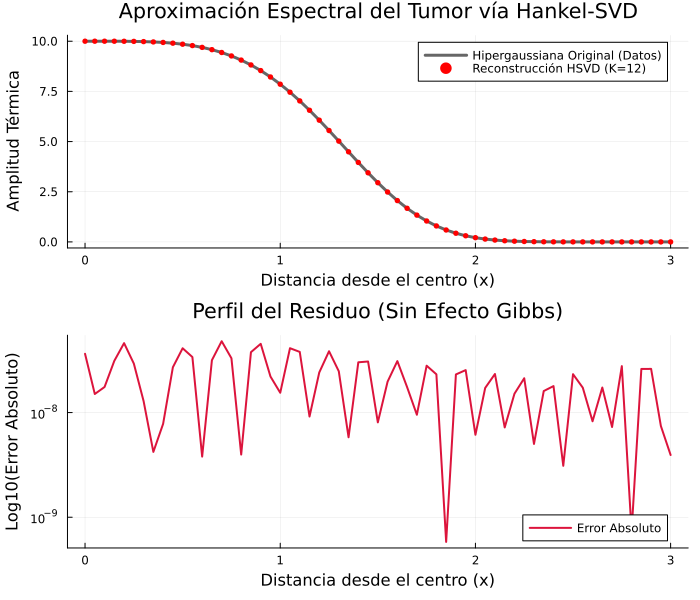

In [2]:
using LinearAlgebra
using Plots
using Printf
"""
    coeficientes_hsvd(y_datos, dx, K; cutoff=1e-12)

Calcula de forma algebraica pura los pesos (w) y exponentes (s) para aproximar
un vector de datos como una suma de exponenciales: y(x) ≈ ∑ w_k * exp(-s_k * x).
"""
function coeficientes_hsvd_complejos(y_datos, dx, K; cutoff=1e-13)
    N = length(y_datos)
    L = div(N, 2)
    M = N - L + 1

    H = [y_datos[i + j - 1] for i in 1:L, j in 1:M]

    U, S, V = svd(H)

    rango_efectivo = count(s -> s > (S[1] * cutoff), S)
    K_real = min(K, rango_efectivo)
    
    println("Valores singulares significativos detectados: ", rango_efectivo)
    println("Usando un rango de K = ", K_real)

    U_k = U[:, 1:K_real]

    U_arriba = U_k[1:(end-1), :]
    U_abajo  = U_k[2:end, :]
    
    Z = pinv(U_arriba) * U_abajo
    q_k = eigvals(Z)

    # --- CORRECCIÓN CLAVE: PRESERVAR EL PLANO COMPLEJO ---
    # Mantenemos s_k como ComplexF64 para no destruir las frecuencias oscilatorias
    s_k = -log.(complex.(q_k)) ./ dx
    
    # 4. Encontrar los pesos (w_k) usando aritmética compleja
    A = zeros(ComplexF64, N, K_real)
    for i in 1:N
        x_i = (i - 1) * dx
        for j in 1:K_real
            A[i, j] = exp(-s_k[j] * x_i)
        end
    end

    # Pesos complejos
    w_k = A \ complex.(y_datos)

    return w_k, s_k
end
# =========================================================================
# EJEMPLO DE USO: Aplicado a la mitad derecha de una Hipergaussiana (m=2)
# =========================================================================

# Configuración del dominio de prueba (mitad derecha del tumor desde el centro x=0)
dx = 0.05
x_prueba = 0.0:dx:3.0
Q_tumor = 10.0
σ = 1.2
m = 2

# Generamos los datos limpios de la hipergaussiana
y_tumor = [Q_tumor * exp(-(x^(2*m)) / (2 * σ^(2*m))) for x in x_prueba]

# =========================================================================
# 1. RECONSTRUCCIÓN CON LOS COEFICIENTES HALLADOS
# =========================================================================
# 1. Calculamos los coeficientes complejos con K=6
w, s = coeficientes_hsvd_complejos(y_tumor, dx, 12)

# 2. Reconstruimos tomando la componente real del resultado
y_reconstruida = [real(sum(w[k] * exp(-s[k] * x) for k in 1:length(w))) for x in x_prueba]

error_absoluto = abs.(y_tumor .- y_reconstruida)
max_error = maximum(error_absoluto)

println("\n--- VERIFICACIÓN NUMÉRICA ---")
println("Error absoluto máximo en todo el dominio: ", max_error)

# --- Mostrar Coeficientes ---
println("\n--- Coeficientes Complejos ---")
for i in 1:length(w)
    println("Término $i -> w: ", round(w[i], digits=3), " | s: ", round(s[i], digits=3))
end

# =========================================================================
# 2. RENDERIZADO DE LA GRÁFICA DE VERIFICACIÓN
# =========================================================================

# Gráfica Principal: Comparativa del perfil del tumor
plt_perfil = plot(x_prueba, y_tumor, 
    label="Hipergaussiana Original (Datos)", 
    linewidth=3, 
    color=:black, 
    alpha=0.6)

scatter!(plt_perfil, x_prueba, y_reconstruida, 
    label="Reconstrucción HSVD (K=$(length(w)))", 
    markersize=3, 
    color=:red, 
    marker=:circle,
    markerstrokewidth=0)

plot!(plt_perfil, 
    title="Aproximación Espectral del Tumor vía Hankel-SVD",
    xlabel="Distancia desde el centro (x)",
    ylabel="Amplitud Térmica",
    legend=:topright,
    grid=true)

# Gráfica Secundaria: El perfil del error (escala logarítmica para ver la precisión)
plt_error = plot(x_prueba, error_absoluto, 
    label="Error Absoluto", 
    linewidth=2, 
    color=:crimson,
    yscale=:log10) # Escala logarítmica para apreciar precisiones extremas

plot!(plt_error, 
    title="Perfil del Residuo (Sin Efecto Gibbs)",
    xlabel="Distancia desde el centro (x)",
    ylabel="Log10(Error Absoluto)",
    legend=:bottomright,
    grid=true)

# Combinamos ambas gráficas en un layout vertical espectacular
plt_final = plot(plt_perfil, plt_error, layout=(2,1), size=(700,600))

display(plt_final)

In [4]:
using ITensors
using LinearAlgebra

# =========================================================================
# 1. GENERACIÓN DEL MPS QUÁNTICO DIRECTO (Sistemas de Qubits / QTT)
# =========================================================================

"""
    generar_mps_hsvd(w, s, L, x_max)

Construye directamente un QTT MPS a partir de los coeficientes analíticos (w, s)
obtenidos mediante Hankel-SVD para un dominio x ∈ [0, x_max] particionado en L qubits.
"""
function generar_mps_hsvd(w, s, L, x_max)
    K = length(w)
    sitios = siteinds("Qubit", L)
    tensores_mps = Vector{ITensor}(undef, L)
    enlaces = [Index(K, "Link,l=$i") for i in 1:(L-1)]
    
    for j in 1:L
        s_fisico = sitios[j]
        
        # --- ATENCIÓN A LA CORRECCIÓN DE ORDENACIÓN ---
        # Invertimos el índice del qubit (L - j + 1) o cambiamos la base 
        # para alinearnos con la estructura interna de almacenamiento de ITensors.
        factor_x = x_max * (2.0^(-(L - j + 1)))
        
        if j == 1
            T = ITensor(s_fisico, enlaces[1])
            for d in 1:2
                valor_d = d - 1
                for k in 1:K
                    # En el primer qubit, inyectamos los pesos w[k]
                    T[s_fisico=>d, enlaces[1]=>k] = w[k] * exp(-s[k] * factor_x * valor_d)
                end
            end
        elseif j == L
            T = ITensor(enlaces[L-1], s_fisico)
            for d in 1:2
                valor_d = d - 1
                for k in 1:K
                    T[enlaces[L-1]=>k, s_fisico=>d] = exp(-s[k] * factor_x * valor_d)
                end
            end
        else
            T = ITensor(enlaces[j-1], s_fisico, enlaces[j])
            for d in 1:2
                valor_d = d - 1
                for k in 1:K
                    T[enlaces[j-1]=>k, s_fisico=>d, enlaces[j]=>k] = exp(-s[k] * factor_x * valor_d)
                end
            end
        end
        tensores_mps[j] = T
    end
    
    return MPS(tensores_mps), sitios
end

# =========================================================================
# 2. EJECUCIÓN Y VERIFICACIÓN EN EL NOTEBOOK
# =========================================================================

# Parámetros de la malla QTT acoplada a tus datos analíticos previos
x_max = 3.0
L = 10  # 2^10 = 1024 puntos de muestreo en el QTT (puedes subirlo a 40 sin sufrir en RAM)

println("--- CONSTRUCCIÓN DEL MPS ANALÍTICO ---")
# Generamos el MPS inyectando tus coeficientes 'w' y 's' (calculados en tu script anterior)
mps_hsvd, sitios = generar_mps_hsvd(w, s, L, x_max)

println("Rango máximo inicial del MPS generado (χ_max): ", maxlinkdim(mps_hsvd))

# --- LA COMPRESIÓN CRUCIAL ---
# Aplicamos el truncamiento SVD nativo para podar las fases complejas y redundancias
# Usamos un cutoff estricto equivalente a tu precisión de error anterior (10^-8)
mps_comprimido = truncate!(mps_hsvd; cutoff=1e-8)

println("\n--- VERIFICACIÓN DE COMPRESIÓN (Maldición del rango rota) ---")
println("Rango máximo final tras compresión SVD (χ_max): ", maxlinkdim(mps_comprimido))
println("Dimensiones de enlace qubit a qubit:")
for i in 1:(L-1)
    println("  Enlace entre Qubit $i y $(i+1) -> χ = ", linkdim(mps_comprimido, i))
end

# =========================================================================
# 3. COMPROBACIÓN CONTRA EL ESPACIO REAL (Fidelidad del Estado)
# =========================================================================
# Pasamos el MPS comprimido a un vector denso cuántico únicamente para comparar
# (Nota: Esto solo se hace para verificación con L bajo; si L=40 esta función explota por RAM)
vector_qtt = vec(Array(prod(mps_comprimido), sitios))

# Malla real que ve el QTT (espaciada uniformemente de forma binaria)
dx_qtt = x_max / (2^L)
x_qtt = [ (i-1)*dx_qtt for i in 1:(2^L) ]

# Hipergaussiana exacta calculada punto a punto en la rejilla cuántica
y_exacta_qtt = [Q_tumor * exp(-(x^(2*m)) / (2 * σ^(2*m))) for x in x_qtt]

# Debido a que el SVD puede devolver soluciones reales con fluctuaciones numéricas complejas
# residuales de la máquina del orden de 10^-16, tomamos la parte real
y_aproximada_qtt = real.(vector_qtt)

# Computamos el residuo final en el Espacio de Hilbert del QTT
error_fidelidad = maximum(abs.(y_exacta_qtt .- y_aproximada_qtt))

println("\n--- VERIFICACIÓN DE FIDELIDAD DEL QTT ---")
println("Error absoluto máximo en la malla QTT (2^$L puntos): ", error_fidelidad)

--- CONSTRUCCIÓN DEL MPS ANALÍTICO ---
Rango máximo inicial del MPS generado (χ_max): 12

--- VERIFICACIÓN DE COMPRESIÓN (Maldición del rango rota) ---
Rango máximo final tras compresión SVD (χ_max): 4
Dimensiones de enlace qubit a qubit:
  Enlace entre Qubit 1 y 2 -> χ = 2
  Enlace entre Qubit 2 y 3 -> χ = 2
  Enlace entre Qubit 3 y 4 -> χ = 2
  Enlace entre Qubit 4 y 5 -> χ = 3
  Enlace entre Qubit 5 y 6 -> χ = 3
  Enlace entre Qubit 6 y 7 -> χ = 3
  Enlace entre Qubit 7 y 8 -> χ = 4
  Enlace entre Qubit 8 y 9 -> χ = 4
  Enlace entre Qubit 9 y 10 -> χ = 2

--- VERIFICACIÓN DE FIDELIDAD DEL QTT ---
Error absoluto máximo en la malla QTT (2^10 puntos): 0.0031559298893621968


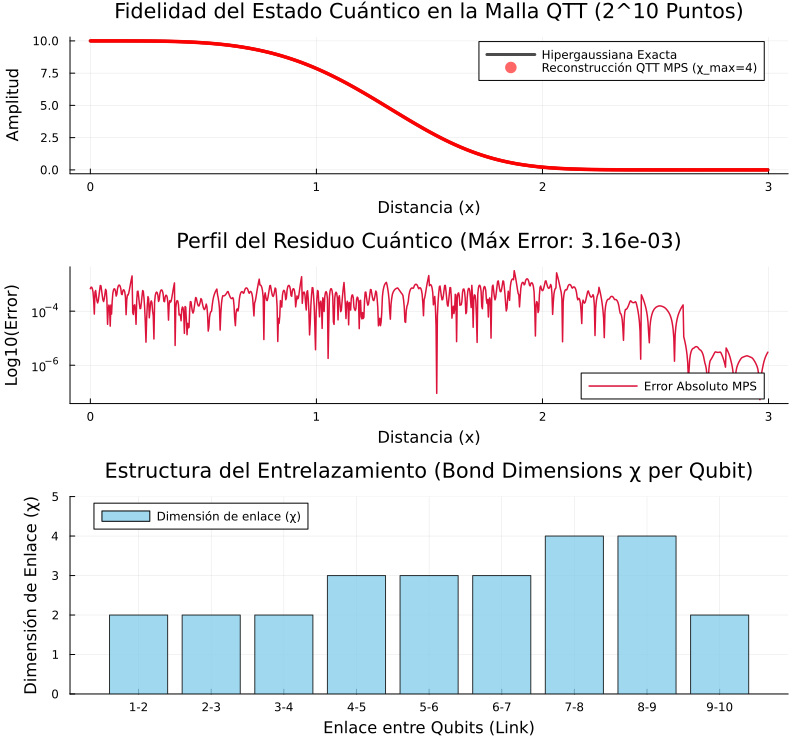

In [5]:
using Plots
using Printf

# =========================================================================
# VISUALIZACIÓN EN EL NOTEBOOK: QTT MPS vs FUNCIÓN EXACTA
# =========================================================================

# 1. Gráfica de perfiles: Comparativa de la función en la malla cuántica
plt_qtt_perfil = plot(x_qtt, y_exacta_qtt, 
    label="Hipergaussiana Exacta", 
    linewidth=3, 
    color=:black, 
    alpha=0.7)

scatter!(plt_qtt_perfil, x_qtt, y_aproximada_qtt, 
    label="Reconstrucción QTT MPS (χ_max=$(maxlinkdim(mps_comprimido)))", 
    markersize=2, 
    color=:red, 
    markerstrokewidth=0,
    alpha=0.6)

plot!(plt_qtt_perfil, 
    title="Fidelidad del Estado Cuántico en la Malla QTT (2^$L Puntos)",
    xlabel="Distancia (x)",
    ylabel="Amplitud",
    legend=:topright,
    grid=true)

# 2. Gráfica de residuos: Perfil del error absoluto en escala logarítmica
error_absoluto_qtt = abs.(y_exacta_qtt .- y_aproximada_qtt)

plt_qtt_error = plot(x_qtt, error_absoluto_qtt, 
    label="Error Absoluto MPS", 
    linewidth=1.5, 
    color=:crimson,
    yscale=:log10)

plot!(plt_qtt_error, 
    title="Perfil del Residuo Cuántico (Máx Error: $(@sprintf("%.2e", error_fidelidad)))",
    xlabel="Distancia (x)",
    ylabel="Log10(Error)",
    legend=:bottomright,
    grid=true)

# 3. Gráfica de Rangos: Dimensión de enlace (Bond Dimension χ) por Qubit
# Extraemos los rangos de cada enlace interno del MPS comprimido
rangos_enlaces = [linkdim(mps_comprimido, i) for i in 1:(L-1)]
etiquetas_qubits = ["$i-$(i+1)" for i in 1:(L-1)]

plt_qtt_rangos = bar(etiquetas_qubits, rangos_enlaces,
    label="Dimensión de enlace (χ)",
    color=:skyblue,
    edgecolor=:blue,
    linewidth=1,
    alpha=0.8)

plot!(plt_qtt_rangos,
    title="Estructura del Entrelazamiento (Bond Dimensions χ per Qubit)",
    xlabel="Enlace entre Qubits (Link)",
    ylabel="Dimensión de Enlace (χ)",
    ylimits=(0, maxlinkdim(mps_comprimido) + 1),
    legend=:topleft,
    grid=true)

# Combinamos los tres gráficos en un layout espectacular: 
# Las dos funciones arriba a la izquierda y derecha, y los rangos abajo ocupando todo el ancho.
layout_notebook = @layout [
    grid(2, 1)
    b{0.35h}
]

plt_dashboard = plot(plt_qtt_perfil, plt_qtt_error, plt_qtt_rangos, 
    layout=layout_notebook, 
    size=(800, 750))

display(plt_dashboard)